# AI 电力需求与电网赤字分析：美国 vs 中国

## 执行摘要
本报告分析了至 2030 年美国和中国 AI 数据中心的预测电力需求，评估了每个国家电网满足这一需求的能力，并量化了电网赤字和相对的结构性瓶颈。

## 验证的假说
*   **H1（结构性赤字瓶颈）**：中美两国在 AI 数据中心上都面临电力短缺。然而，美国的瓶颈在于制度和监管（电网并网排队、许可审批延迟、ISO/RTO 区域碎片化），而中国的瓶颈在于地缘政治和地理（芯片技术受限、西部发电基地与东部需求中心的区域不匹配）。
*   **H2（可再生能源部署速度）**：中国国家主导的电网规划和集中投资使其能够比美国市场驱动、碎片化的电网系统更快地部署可再生能源容量（太阳能、风能）和输电通道（特高压 UHV 输电线）并连接到数据中心。
*   **H3（私营核电贡献）**：美国云厂商（Hyperscalers）在很大程度上依赖双边、非并网购电协议（PPA）——尤其是共用场地的核电站——来绕过电网连接排队，贡献了显著的容量（已签约 2.45 GW），而中国云厂商则依赖国家从大规模国家风光基地分配的容量。


In [1]:
import pandas as pd
import numpy as np

print("Loading US vs. China AI Power Deficit Comparison Table...")
df_comp = pd.read_csv("../output/tables/us_china_comparison.csv")
df_comp


Loading US vs. China AI Power Deficit Comparison Table...


,parameter,us_value,china_value,unit,description
0,AI GPU Blended Power TDP,0.7 kW,0.7 kW,kW,Blended average TDP per active GPU node
1,"Projected Active GPUs (Medium, 2030)",8.0 million,2.0 million,million,Projected active equivalent GPU footprint
2,"Bottom-up AI Power Demand (Low, 2030)",4.38 GW,0.88 GW,GW,Estimated power load in Low deployment scenario
3,"Bottom-up AI Power Demand (Medium, 2030)",7.0 GW,1.75 GW,GW,Estimated power load in Medium deployment scen...
4,"Bottom-up AI Power Demand (High, 2030)",10.5 GW,3.06 GW,GW,Estimated power load in High deployment scenario
5,Top-down Projected Consumption (2030),330.0 TWh (37.67 GW),380.0 TWh (43.38 GW),TWh (GW),Top-down projections from EPRI (US Medium) and...
6,Bilateral Secured PPAs (Nuclear/Geothermal),2.448 GW,0.0 GW,GW,Secured bilateral clean energy contracts by hy...
7,Net Grid Power Required (2030 Medium),4.55 GW,1.75 GW,GW,Projected demand that must go through standard...
8,Grid Interconnection Queue Wait Time,5.0 years,N/A (Centralized planning),years,Average wait time in grid interconnection queue
9,Grid Capacity Metric,Queue: 2600.0 GW,UHV Line Capacity: 150.0 GW,GW,US active interconnection queue capacity vs Ch...


Demand Projections (TWh/year):


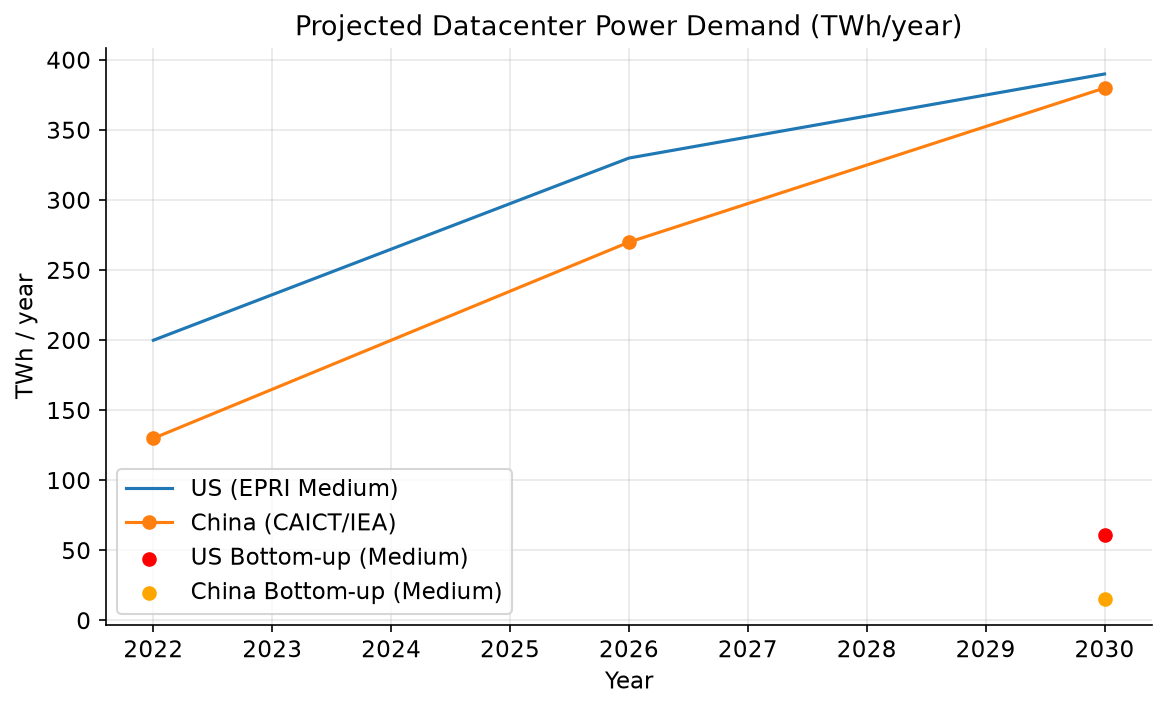

In [2]:
from IPython.display import Image, display
print("Demand Projections (TWh/year):")
display(Image(filename="../output/figures/demand_scenarios.png"))


Grid Infrastructure Bottlenecks:


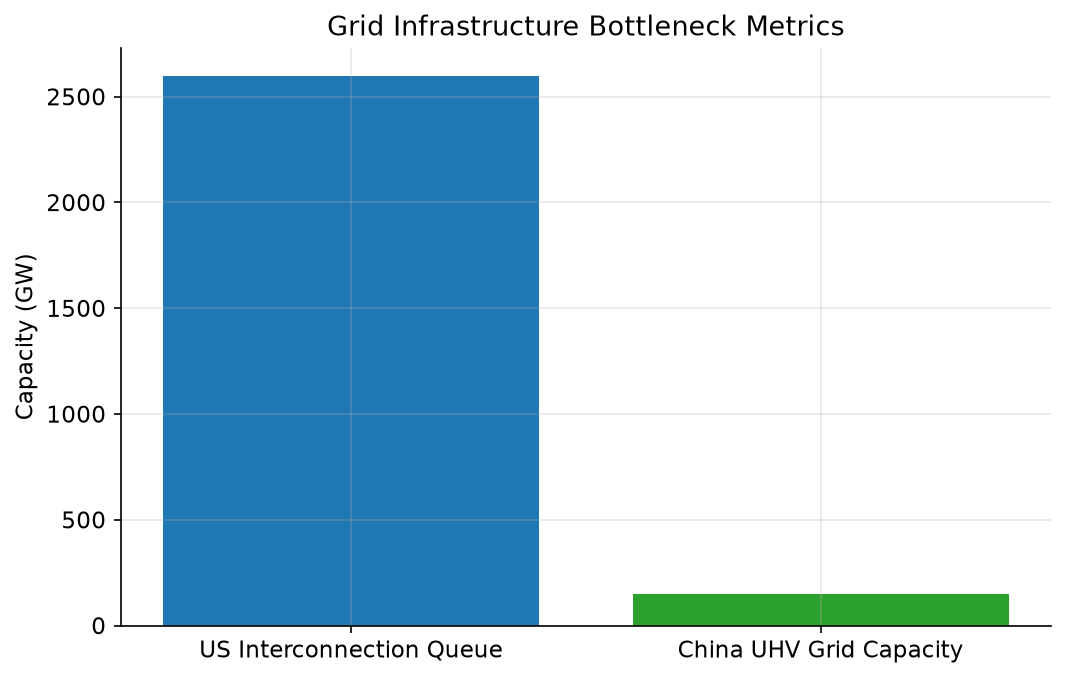

In [3]:
print("Grid Infrastructure Bottlenecks:")
display(Image(filename="../output/figures/bottlenecks.png"))


## 讨论与关键发现

### 1. 比较优势与劣势

#### **美国**
*   **优势**：处于前沿的 GPU 芯片设计和获取通道（无出口管制），云厂商（微软、亚马逊、谷歌、Meta）拥有庞大的资本可用性。
*   **劣势（制度性瓶颈）**：电网极度破碎。**并网申请排队等待时间平均为 5.0 年**（LBNL 数据），有超过 **2600 GW** 的容量在排队中停滞。NEPA 和 FERC 监管下的许可审批障碍拖慢了新输电线的建设。
*   **缓解策略（私营核电 PPA - 支持 H3）**：云厂商通过直接与核电站（Constellation、Talen）签约共用场地数据中心，绕过了电网排队。总共锁定的双边容量为 **2.448 GW**（包括微软的三哩岛协议和亚马逊的萨斯奎哈纳协议），这覆盖了预测的 7.0 GW 美国自下而上中值 AI 需求的 **35%**。

#### **中国**
*   **优势（国家电网效率 - 支持 H2）**：集中式的国家主导电网规划。国家电网和南方电网建设了容量高达 **150 GW 的庞大特高压（UHV）输电网络**，使 **“东数西算”** 项目能够将西部省份（宁夏、贵州、甘肃）的风光电力直接输送到东部计算中心。
*   **劣势**：前沿 GPU 芯片进口受到地缘政治限制（限制了高热设计功耗 TDP GPU 的总部署规模）。
*   **缓解策略**：最大限度地利用中国西部的本地化绿电基地，依赖政府分配的绿电目标，而不是私营的共用场地 PPA。

### 2. 赤字分析
*   **美国赤字**：时间和结构性赤字。尽管到 2030 年自下而上的中值需求仅为 7.0 GW（61.32 TWh/年），但由于 5 年的排队，数据中心无法在通常的 1-2 年建设窗口内获得电网连接。非并网核电 PPA 缓解了这一问题，但仅限于现有的核电站场地，这创造了一个硬性的物理天花板。
*   **中国赤字**：不是电力或传输赤字，而是技术和芯片赤字。中国拥有充足的位置和特高压容量（150 GW）以及西部绿电，但缺乏先进的高功率 GPU 来将这些数据中心填充到与美国相同的密度。

## 结论
*   **H1（瓶颈）得到支持**：美国的瓶颈在制度 and 监管（排队等待 5 年）；中国的瓶颈在技术和芯片。
*   **H2（可再生能源速度）得到支持**：中国集中式的特高压规划（150 GW 容量）相比于美国碎片化的市场，能够更快地将绿电输送到计算枢纽。
*   **H3（核电 PPA）得到支持**：美国云厂商在直接清洁能源 PPA 方面处于领先地位（已锁定 2.45 GW 容量），而中国不使用共用场地的私营核电模式。
